In [ ]:
import pandas as pd
from pathlib import Path

data_path = Path("data/raw/diabetic_data.csv")
if not data_path.exists():
    data_path = Path("..") / "data" / "raw" / "diabetic_data.csv"

df = pd.read_csv(data_path, na_values="?")

df.head()

C:\Users\ameni\AppData\Local\Temp\ipykernel_18296\3988152560.py:3: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/diabetic_data.csv", na_values="?")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
# Dimensions du dataset
print("Shape:", df.shape)

# Informations sur les colonnes (types, valeurs non-nulles)
df.info()

Shape: (101766, 50)
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medicat

In [3]:
# La colonne "readmitted" indique si le patient a Ã©tÃ© rÃ©hospitalisÃ©
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [4]:
# Transformation en classification binaire
# 1 = rÃ©hospitalisÃ© dans les 30 jours (risque), 0 = sinon
df['target'] = (df['readmitted'] == '<30').astype(int)

# VÃ©rification
df['target'].value_counts(normalize=True) * 100

target
0    88.840084
1    11.159916
Name: proportion, dtype: float64

In [5]:
# On garde uniquement la première hospitalisation de chaque patient
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')

print("Nombre de lignes après déduplication:", len(df))

# Révision de la distribution de la cible après déduplication
df['target'].value_counts(normalize=True) * 100

# Exclusion des sorties par décès ou hospice (codes 11, 13, 14, 19, 20, 21)
codes_deces_hospice = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(codes_deces_hospice)]

print("Lignes restantes après exclusion décès/hospice:", len(df))

# Vérification du genre invalide
print(df['gender'].value_counts())


Nombre de lignes après déduplication: 71518
Lignes restantes après exclusion décès/hospice: 69973
gender
Female             37229
Male               32741
Unknown/Invalid        3
Name: count, dtype: int64


In [6]:
# Suppression des colonnes trop incomplÃ¨tes ou peu pertinentes
df = df.drop(columns=['weight', 'payer_code'])

# Remplacement des NaN par une catÃ©gorie explicite (pas une vraie valeur manquante)
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not tested')
df['A1Cresult'] = df['A1Cresult'].fillna('Not tested')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['race'] = df['race'].fillna('Unknown')
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

# VÃ©rification finale
print(df.isnull().sum().sum())  # doit Ãªtre 0

0


In [7]:
# Nombre de patients uniques vs nombre total de sÃ©jours
print("SÃ©jours totaux:", len(df))
print("Patients uniques:", df['patient_nbr'].nunique())

# RÃ©partition du nombre de sÃ©jours par patient
df['patient_nbr'].value_counts().describe()

SÃ©jours totaux: 69973
Patients uniques: 69973


count    69973.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: count, dtype: float64

In [8]:
# On garde uniquement la premiÃ¨re hospitalisation de chaque patient
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')

print("Nombre de lignes apres de duplication:", len(df))

Nombre de lignes apres de duplication: 69973


In [9]:
# 1. Vérification répartition cible après dédup
print(df['target'].value_counts(normalize=True) * 100)

target
0    91.029397
1     8.970603
Name: proportion, dtype: float64


In [10]:
# 2. Exclusion des sorties par décès ou hospice
codes_deces_hospice = [11, 13, 14, 19, 20, 21]
avant = len(df)
df = df[~df['discharge_disposition_id'].isin(codes_deces_hospice)]
print(f"Lignes retirées (décès/hospice): {avant - len(df)}")
print(f"Lignes restantes: {len(df)}")

Lignes retirées (décès/hospice): 0
Lignes restantes: 69973


In [11]:
# 3. Vérification du genre
print(df['gender'].value_counts())

gender
Female             37229
Male               32741
Unknown/Invalid        3
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

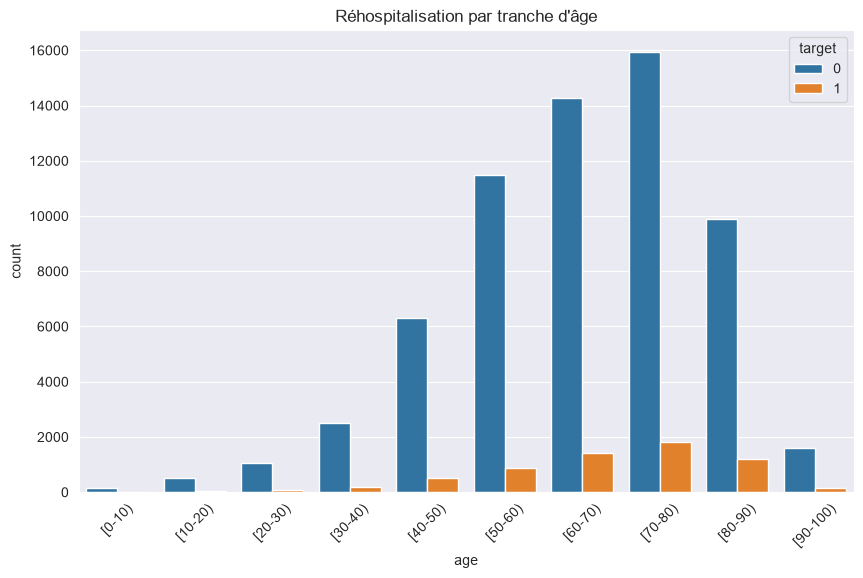

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='age', hue='target', order=sorted(df['age'].unique()))
plt.xticks(rotation=45)
plt.title("Réhospitalisation par tranche d'âge")
plt.show()

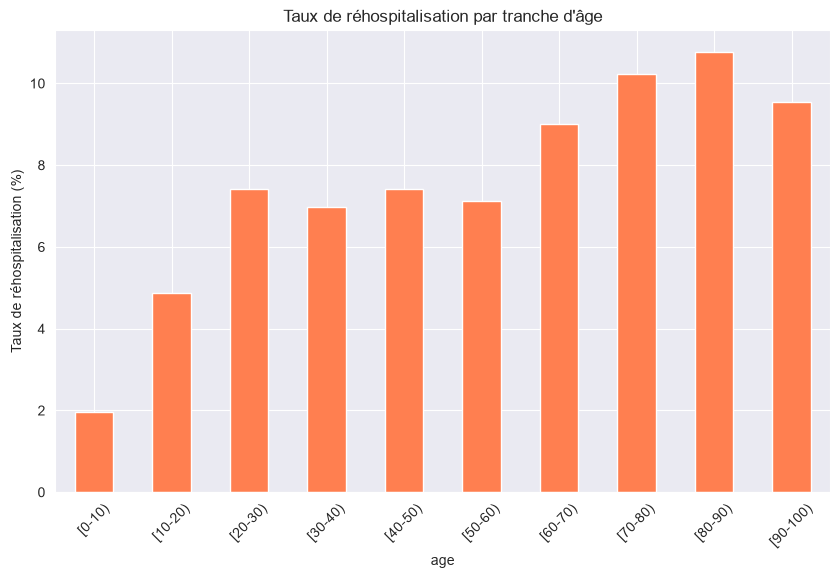

In [14]:
# Taux de réhospitalisation par tranche d'âge (en %)
age_target = df.groupby('age')['target'].mean().sort_index() * 100

plt.figure(figsize=(10,6))
age_target.plot(kind='bar', color='coral')
plt.ylabel("Taux de réhospitalisation (%)")
plt.title("Taux de réhospitalisation par tranche d'âge")
plt.xticks(rotation=45)
plt.show()

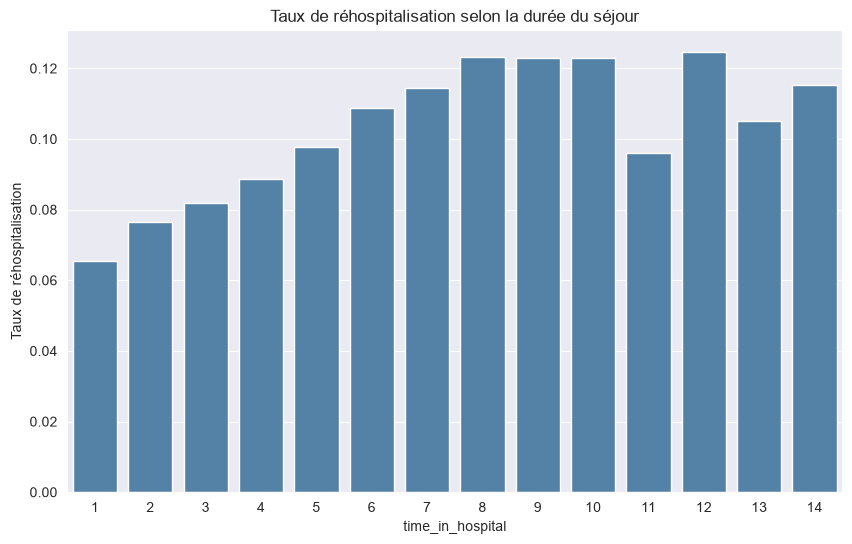

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='time_in_hospital', y='target', color='steelblue', errorbar=None)
plt.ylabel("Taux de réhospitalisation")
plt.title("Taux de réhospitalisation selon la durée du séjour")
plt.show()

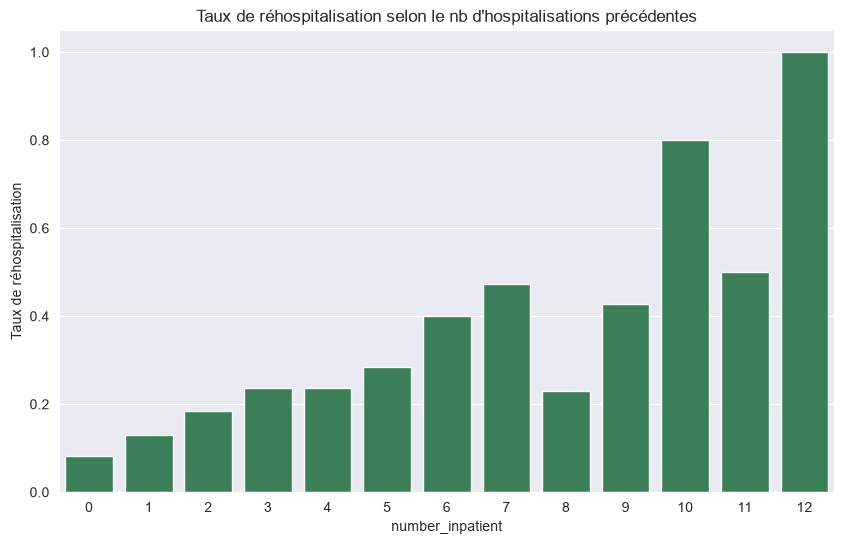

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='number_inpatient', y='target', color='seagreen', errorbar=None)
plt.ylabel("Taux de réhospitalisation")
plt.title("Taux de réhospitalisation selon le nb d'hospitalisations précédentes")
plt.show()

In [17]:
# Vérifier les effectifs par valeur de number_inpatient
df['number_inpatient'].value_counts().sort_index()

number_inpatient
0     61782
1      5794
2      1501
3       463
4       228
5       102
6        55
7        19
8        13
9         7
10        5
11        2
12        2
Name: count, dtype: int64

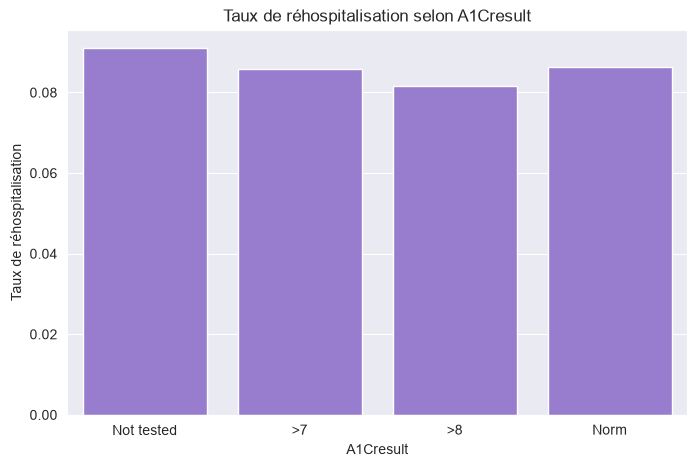

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='A1Cresult', y='target', color='mediumpurple', errorbar=None)
plt.ylabel("Taux de réhospitalisation")
plt.title("Taux de réhospitalisation selon A1Cresult")
plt.show()

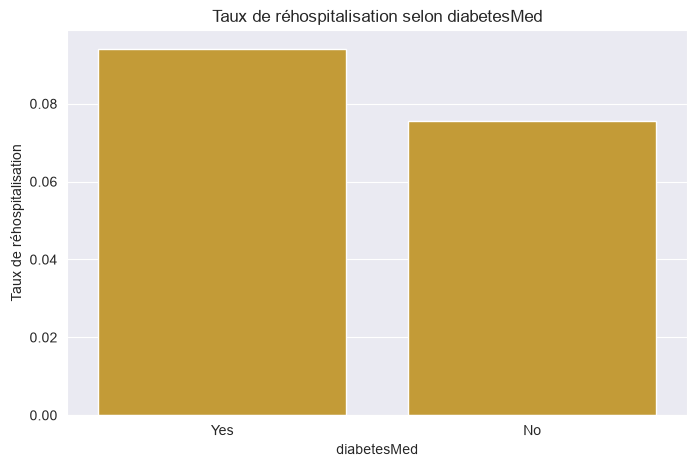

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='diabetesMed', y='target', color='goldenrod', errorbar=None)
plt.ylabel("Taux de réhospitalisation")
plt.title("Taux de réhospitalisation selon diabetesMed")
plt.show()

In [ ]:
plt.figure(figsize=(9,5))sns.barplot(data=df, x='race', y='target', color='coral', errorbar=None)plt.ylabel("Taux de réhospitalisation")plt.title("Taux de réhospitalisation selon race")plt.xticks(rotation=30)plt.show()

In [ ]:
plt.figure(figsize=(8,5))sns.barplot(data=df, x='insulin', y='target', color='teal', errorbar=None)plt.ylabel("Taux de réhospitalisation")plt.title("Taux de réhospitalisation selon insulin")plt.show()

In [ ]:
print(df['race'].value_counts())print()print(df['insulin'].value_counts())

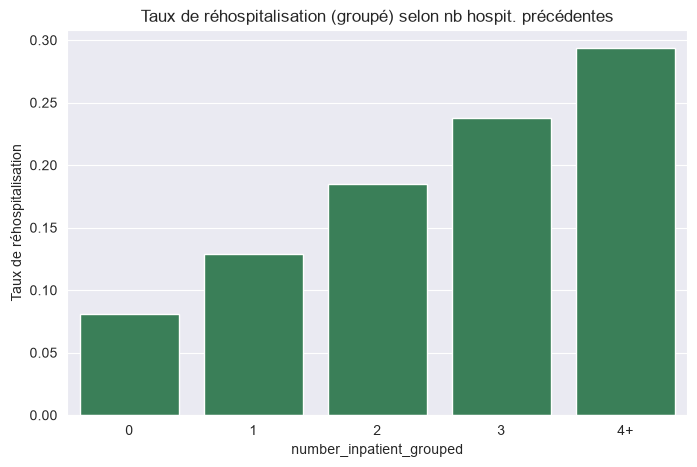

In [20]:
# Regroupement des valeurs rares (4 hospitalisations précédentes ou plus)
df['number_inpatient_grouped'] = df['number_inpatient'].apply(lambda x: '4+' if x >= 4 else str(x))

# Vérification du nouveau taux par groupe
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='number_inpatient_grouped', y='target', 
            order=['0','1','2','3','4+'], color='seagreen', errorbar=None)
plt.ylabel("Taux de réhospitalisation")
plt.title("Taux de réhospitalisation (groupé) selon nb hospit. précédentes")
plt.show()

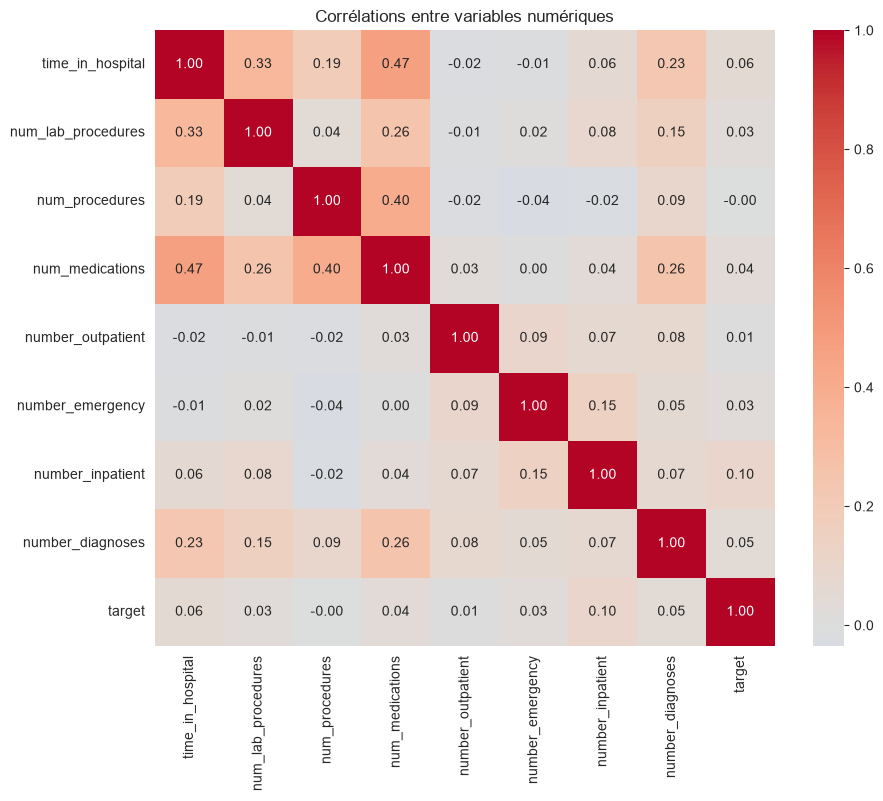

In [21]:
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                 'num_medications', 'number_outpatient', 'number_emergency', 
                 'number_inpatient', 'number_diagnoses', 'target']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Corrélations entre variables numériques")
plt.show()